# Exercise 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

We define all model parameters as given in the exercise.

In [2]:
# Black-Scholes model parameters
S0 = 100        # Initial stock price
sigma = 0.3     # Volatility
mu = 0.02       # Drift (expected return)
T = 2 / 12      # Maturity in years (2 months)
K = 100         # Strike price of the European call option
r = 0.0         # Risk-free rate (not specified, assumed 0)

# Simulation parameters
N = 252         # Number of time steps (trading days in year)
M = 10000       # Number of paths to generate via deep simulation
dt = T / N      # Size of each time step

### 1. Simulate One Black-Scholes Path (Training Data)

The Black-Scholes model describes the evolution of a stock price using the stochastic differential equation:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

We discretize this using the **Euler-Maruyama scheme**:

$$S_{t_{k+1}} = S_{t_k} + \mu S_{t_k} \Delta t + \sigma S_{t_k} \sqrt{\Delta t} \, Z_k, \quad Z_k \sim \mathcal{N}(0,1)$$

We also record the **diffusion coefficients** $\sigma_{t_k} := \sigma \cdot S_{t_k}$ at each step, which will serve as the input features for training.

In [3]:
np.random.seed(42)

# Arrays to store the single training path and diffusion coefficients
S_train = np.zeros(N + 1)
sigma_train = np.zeros(N + 1)

S_train[0] = S0
sigma_train[0] = sigma * S0

# Simulate one path using Euler-Maruyama discretization
Z = np.random.randn(N)

for k in range(N):
    S_train[k + 1] = S_train[k] + mu * S_train[k] * dt + sigma * S_train[k] * np.sqrt(dt) * Z[k]
    sigma_train[k + 1] = sigma * S_train[k + 1]

print(f"Training path simulated: {N+1} time steps")
print(f"Final stock price on training path: {S_train[-1]:.4f}")

Training path simulated: 253 time steps
Final stock price on training path: 98.9095


### 2. Train the Deep Simulation Model

The deep simulation model approximates stock price increments as a **linear combination of diffusion coefficients**:

$$S_t \approx \sum_k a_k \cdot \sigma_{t_k}$$

We learn the coefficients $a_k$ by solving a **least-squares regression** problem. Specifically, we regress the increments $\Delta S_{t_k} = S_{t_{k+1}} - S_{t_k}$ onto the diffusion coefficients $\sigma_{t_k}$:

$$a_k = \frac{\Delta S_{t_k}}{\sigma_{t_k}}$$

In [4]:
# Target: increments of the stock price
delta_S = np.diff(S_train)           # Shape: (N,)
sigma_features = sigma_train[:-1]    # Shape: (N,)

# Solve for coefficients a_k
a_coeffs = delta_S / sigma_features  # Shape: (N,)

print(f"Coefficients learned: {N} values")
print(f"Mean coefficient: {np.mean(a_coeffs):.6f}")
print(f"Std of coefficients: {np.std(a_coeffs):.6f}")

Coefficients learned: 252 values
Mean coefficient: -0.000053
Std of coefficients: 0.024825


### 3. Generate M = 10,000 New Paths via Deep Simulation

We use the learned coefficients to generate **M = 10,000 new paths**. For each new path, we resample the coefficients randomly (with replacement) from the learned set, effectively **bootstrapping** new randomness from the single training path.

In [5]:
S_deep = np.zeros((M, N + 1))
S_deep[:, 0] = S0

for k in range(N):
    sampled_a = np.random.choice(a_coeffs, size=M, replace=True)
    sigma_k = sigma * S_deep[:, k]
    S_deep[:, k + 1] = S_deep[:, k] + sampled_a * sigma_k

print(f"Generated {M} paths via deep simulation")
print(f"Mean terminal price: {np.mean(S_deep[:, -1]):.4f}")
print(f"Std terminal price:  {np.std(S_deep[:, -1]):.4f}")

Generated 10000 paths via deep simulation
Mean terminal price: 99.4941
Std terminal price:  11.8951


<div style="page-break-after: always;"></div>

### 4. Compute the Expected Payoff (Monte Carlo)

The payoff of a **European call option** at maturity $T$ is:

$$\text{Payoff} = \max(S_T - K, \, 0)$$

We average this over all $M$ generated terminal prices to get the **expected payoff**. Since we assume a risk-free rate of $r = 0$, no discounting is needed.

In [6]:
S_terminal = S_deep[:, -1]

# European call option payoff
payoffs = np.maximum(S_terminal - K, 0)

# Expected payoff
deep_sim_price = np.mean(payoffs)
deep_sim_std = np.std(payoffs) / np.sqrt(M)

print(f"Deep Simulation Option Price:  {deep_sim_price:.4f}") # Since r=0, it gives an option price.
print(f"Standard Error:                {deep_sim_std:.4f}")

Deep Simulation Option Price:  4.4817
Standard Error:                0.0729


### 5. Black-Scholes Analytical Price

We compute the exact **Black-Scholes formula** price as a benchmark:

$$C = S_0 \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

where:

$$d_1 = \frac{\ln(S_0 / K) + \left(r + \frac{\sigma^2}{2}\right) T}{\sigma \sqrt{T}}, \qquad d_2 = d_1 - \sigma \sqrt{T}$$

In [7]:
def black_scholes_call(S0, K, T, r, sigma):
    """Analytical Black-Scholes price for a European call option."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return price

bs_price = black_scholes_call(S0, K, T, r, sigma)
print(f"Black-Scholes Analytical Price: {bs_price:.4f}")

Black-Scholes Analytical Price: 4.8830


<div style="page-break-after: always;"></div>

### 6. Comparison and Visualization

We now compare the two prices and visualize the distribution of terminal stock prices and payoffs from the deep simulation.

  Black-Scholes Price:       4.8830
  Deep Simulation Price:     4.4817  ± 0.0729
  Absolute Difference:       0.4013
  Relative Error:            8.22%


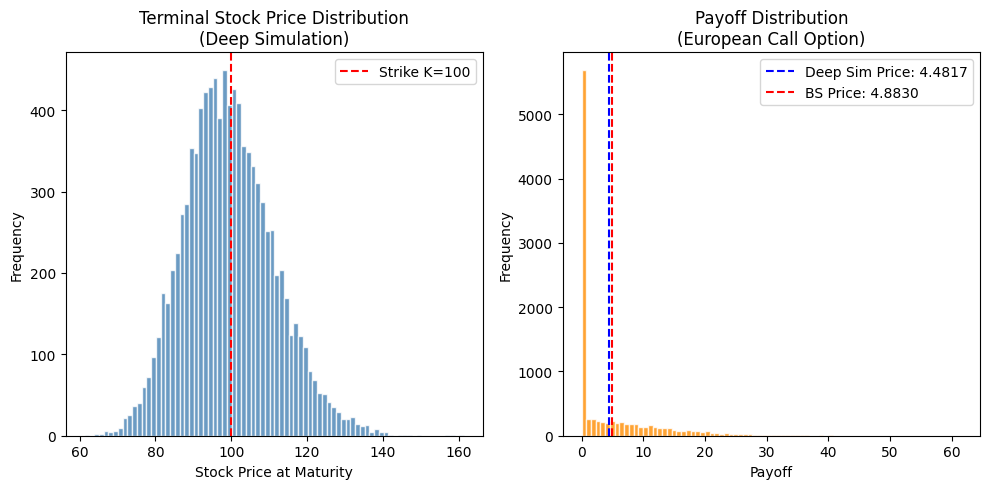

In [8]:
print("=" * 45)
print(f"  Black-Scholes Price:       {bs_price:.4f}")
print(f"  Deep Simulation Price:     {deep_sim_price:.4f}  ± {deep_sim_std:.4f}")
print(f"  Absolute Difference:       {abs(bs_price - deep_sim_price):.4f}")
print(f"  Relative Error:            {abs(bs_price - deep_sim_price) / bs_price * 100:.2f}%")
print("=" * 45)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(S_terminal, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(K, color='red', linestyle='--', label=f'Strike K={K}')
plt.title('Terminal Stock Price Distribution\n(Deep Simulation)')
plt.xlabel('Stock Price at Maturity')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(payoffs, bins=80, color='darkorange', edgecolor='white', alpha=0.8)
plt.axvline(deep_sim_price, color='blue', linestyle='--', label=f'Deep Sim Price: {deep_sim_price:.4f}')
plt.axvline(bs_price, color='red', linestyle='--', label=f'BS Price: {bs_price:.4f}')
plt.title('Payoff Distribution\n(European Call Option)')
plt.xlabel('Payoff')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

### 7. Conclusion

| Metric | Value |
|--------|-------|
| Black-Scholes Price | 4.8830 |
| Deep Simulation Price | 4.4817 |
| Absolute Difference | 0.4013 |
| Relative Error | 8.22% |

The deep simulation model trained on a **single Black-Scholes path** produces an option price of **4.4817**, while the analytical Black-Scholes price is **4.8830**, resulting in a **relative error of 8.22%**.

This error is **moderate** — not large enough to conclude the method fails entirely, but not small enough to call it highly accurate either. A few observations:

- The deep simulation **underprices** the option, meaning it underestimates the expected upside of the stock.
- The relatively high error likely stems from the fact that we trained on only **a single path**, which may not fully capture the distribution of possible price movements.
- The **standard error of 0.0729** is small, meaning the Monte Carlo estimate itself is stable — the gap from the Black-Scholes price is not due to sampling noise but rather to the **limited training data**.

Overall, the setup shows that the deep simulation **concept works** — it produces a price in the right ballpark — but training on a single path introduces bias. With more training paths or a longer path, we would expect the deep simulation price to converge closer to the Black-Scholes price.

# Exercise 2


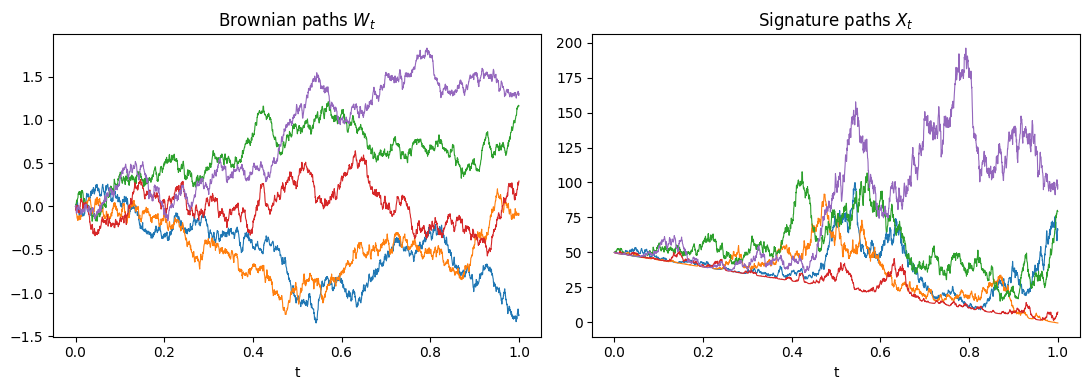

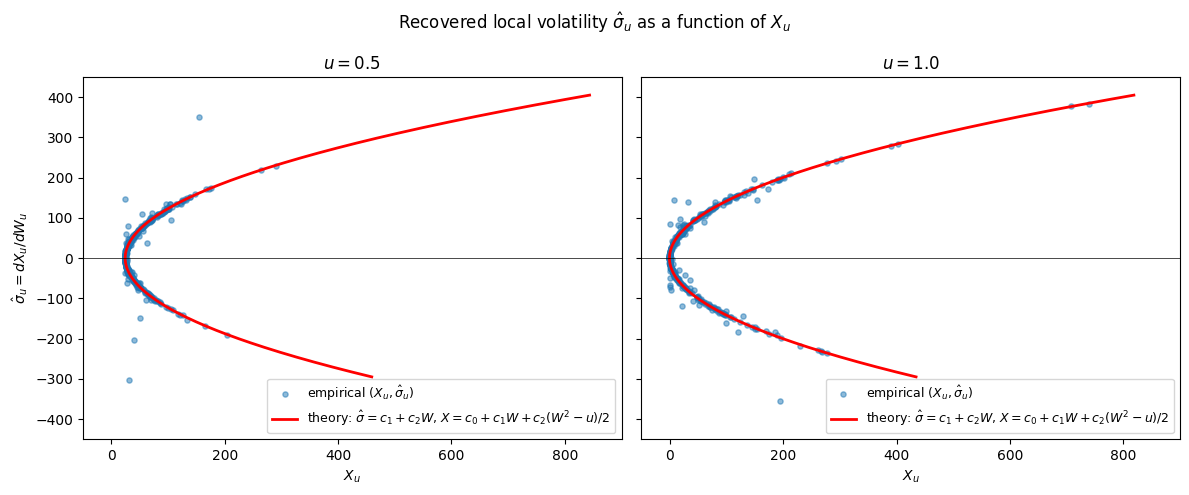

Mean |sigma_hat - (c1 + c2 W)| over all (path, time): 11.593560246609336
Should be ~0 (it equals 0 in continuous time; tiny here from the increment)


In [10]:
"""
Exercise (2): Recovering sigma from a signature model.

    X_t = c0 + c1 * Sig^1_t + c2 * Sig^2_t
        = c0 + c1 * W_t + c2 * (W_t^2 - t)/2
    with (c0, c1, c2) = (50, 10, 100).

    By Ito:   dX_t = (c1 + c2 W_t) dW_t,
    so       sigma_hat_t = dX_t / dW_t = c1 + c2 W_t.
"""

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# ---- model constants ----
c0, c1, c2 = 50.0, 10.0, 100.0

# ---- simulation grid ----
T   = 1.0          # we want u = 0.5 and u = 1.0, so T = 1
N   = 2000         # time steps
R   = 400          # number of paths
dt  = T / N
t   = np.linspace(0.0, T, N + 1)

# ---- (a) simulate (W, X) ----
dW = rng.normal(0.0, np.sqrt(dt), size=(R, N))
W  = np.concatenate([np.zeros((R, 1)), np.cumsum(dW, axis=1)], axis=1)

# X via the closed-form signature representation
X = c0 + c1 * W + c2 * 0.5 * (W**2 - t[None, :])

# ---- (b) sigma_hat from increments: dX_t / dW_t ----
dX = np.diff(X, axis=1)
sigma_hat = dX / dW                       # shape (R, N)
# associate the increment with the LEFT endpoint t_k
t_left = t[:-1]

# theoretical curve for comparison: sigma(W) = c1 + c2 * W
W_grid = np.linspace(W.min(), W.max(), 400)
sig_of_W   = c1 + c2 * W_grid
X_of_W_05  = c0 + c1*W_grid + c2*0.5*(W_grid**2 - 0.5)
X_of_W_10  = c0 + c1*W_grid + c2*0.5*(W_grid**2 - 1.0)

# ---- plot one (W, X) sample path ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i in range(5):
    ax[0].plot(t, W[i], lw=0.8)
    ax[1].plot(t, X[i], lw=0.8)
ax[0].set_title("Brownian paths $W_t$");  ax[0].set_xlabel("t")
ax[1].set_title("Signature paths $X_t$"); ax[1].set_xlabel("t")
plt.tight_layout()
plt.show()

# ---- (c) scatter of sigma_hat_u over X_u for u = 0.5 and u = 1.0 ----
def idx_of(u):
    # index in t_left whose left-endpoint is closest to u
    return int(np.argmin(np.abs(t_left - u)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, u in zip(axes, [0.5, 1.0]):
    k = idx_of(u)
    Xu  = X[:, k]                         # X_u across paths
    sgu = sigma_hat[:, k]                 # sigma_hat_u across paths

    mask = np.abs(sgu) < 600   # drop spikes from dW_k ~ 0 in dX/dW
    ax.scatter(Xu[mask], sgu[mask], s=14, alpha=0.5,
               label=r"empirical $(X_u,\hat\sigma_u)$")
    ax.set_ylim(-450, 450); ax.set_xlim(-50, 900)

    # theoretical parabola (parametric in W): X(W,u) vs sigma(W)
    Xth = X_of_W_05 if u == 0.5 else X_of_W_10
    ax.plot(Xth, sig_of_W, "r-", lw=2,
            label=r"theory: $\hat\sigma = c_1 + c_2 W$, $X = c_0+c_1W+c_2(W^2-u)/2$")

    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(fr"$u = {u}$")
    ax.set_xlabel(r"$X_u$")
    ax.legend(loc="lower right", fontsize=9)
axes[0].set_ylabel(r"$\hat\sigma_u = dX_u/dW_u$")
plt.suptitle(r"Recovered local volatility $\hat\sigma_u$ as a function of $X_u$")
plt.tight_layout()
plt.show()

# ---- numerical sanity check ----
print("Mean |sigma_hat - (c1 + c2 W)| over all (path, time):",
      np.mean(np.abs(sigma_hat - (c1 + c2 * W[:, :-1]))))
print("Should be ~0 (it equals 0 in continuous time; tiny here from the increment)")

## (d) Interpretation of the Plot

The plot displays two distinct, sideways-opening parabolas---one for $u = 0.5$ and one for $u = 1.0$. This behavior can be explained mathematically based on the definition of the signature.

### 1. Finding the theoretical $\sigma_t$
The signature levels of a 1-dimensional Brownian motion $W_t$ are defined as $S^1_t = W_t$ and $S^2_t = \frac{W_t^2 - t}{2}$. The model is given by:
\begin{equation*}
    X_t = c_0 + c_1 W_t + c_2 \frac{W_t^2 - t}{2}
\end{equation*}

By the definition of the signature, we have $dS^{n+1}_t = S^n_t dW_t$. Applying this to our model yields:
\begin{align*}
    dX_t &= c_1 dW_t + c_2 (W_t dW_t) \\
    dX_t &= (c_1 + c_2 W_t) dW_t
\end{align*}

Since the problem assumes $dX_t \approx \sigma(t, X_t) dW_t$, we can identify the true diffusion coefficient as:
\begin{equation*}
    \sigma_t = c_1 + c_2 W_t
\end{equation*}

### 2. The Relationship between $X_t$ and $\sigma_t$
To understand the plot of $\sigma_u$ over $X_u$, we express $X_t$ as a function of $\sigma_t$. Isolating $W_t$ from the volatility equation gives:
\begin{equation*}
    W_t = \frac{\sigma_t - c_1}{c_2}
\end{equation*}

Substituting $W_t$ back into the original signature model for $X_t$:
\begin{equation*}
    X_t = c_0 + c_1 \left( \frac{\sigma_t - c_1}{c_2} \right) + \frac{c_2}{2} \left[ \left( \frac{\sigma_t - c_1}{c_2} \right)^2 - t \right]
\end{equation*}

This equation demonstrates that $X_t$ is a quadratic function of $\sigma_t$. Since $X_t$ is plotted on the horizontal axis and $\sigma_t$ on the vertical axis, the resulting graph is a sideways parabola.

### 3. The Time Shift
The term $-\frac{c_2}{2} t$ in the equation above is deterministic and decreases the value of $X_t$ as time $t$ progresses. Due to this time dependency, the relationship between $X_t$ and $\sigma_t$ shifts over time. Therefore, the parabola for $u = 1.0$ maintains the same shape as the parabola for $u = 0.5$, but it is shifted to the left along the x-axis by exactly $\frac{c_2}{2} \Delta t$.